# Notebook to develop codes:

**Remark:** 
 * I work in my local branch (edmond-dev)
 * For now it turns with `desilike/dr2-dev`

In [4]:
"""
Script to fit png from the data.
"""

import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')


# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [5]:
from tools import read_data, rebin_data, get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

def plot_corr(cov, fn=None): 
    import matplotlib.text
    import re
    
    fig = cov.plot(corrcoef=True, figsize=(9,9))
    for txt in fig.findobj(matplotlib.text.Text):
        s = txt.get_text()
        s = s.replace('spectrum2,', '').replace(',spectrum2', '').replace('spectrum2', '')
        s = re.sub(r'\b(\w+)_\1\b', r'\1', s)   # LRG_LRG -> LRG
        s = s.replace('_', 'x')                 # LRG_QSO -> LRGxQSO
        s = s.replace('\nx ', '\n')             # remove "x " prefix on second line
        if '\n' in s: txt.set_fontsize(8)
        txt.set_text(s)
    if fn is not None: plt.savefig(fn)
    plt.show()

In [6]:
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

data_dir =  '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[visitor-10-59-21-254.wifi.berkeley.edu:57845] shmem: mmap: an error occurred while determining whether or not /var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T//ompi.visitor-10-59-21-254.501/jf.0/3581083648/sm_segment.visitor-10-59-21-254.501.d5730000.0 could be created.


[000000.00] [0/1] 04-27 18:27  FIT PNG                   INFO     Load data from: /Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/


In [7]:
def propose_fiducial():
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': 1e-2, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': 4e-3, 'kmax': 0.08, 'kmin_ell2': 3e-3, 'kmax_ell2': 0.08}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08, 'kmin_ell2': 1e-3, 'kmax_ell2': 0.08}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': 4e-3, 'kmax': 0.08, 'kmin_ell2': 3e-3, 'kmax_ell2': 0.08}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['ELGxQSO']
      
    return propose_fiducial

fiducial = propose_fiducial()
tracers_to_read = ['LRG', 'ELGnotqso', 'QSO', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO']

pks, windows, covs, mocks, zeffs = {}, {}, {}, {}, {}
for tracer in tracers_to_read:
    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, add_ic=True, 
                                       aladr1=True, weight_type_mocks='default-fkp-oqe', **fiducial[short_tracer])
    
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, **fiducial[short_tracer])
    
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')
   
    if 'x' not in short_tracer: short_tracer = 'x'.join(2*[short_tracer])
    pks[short_tracer], windows[short_tracer], covs[short_tracer], mocks[short_tracer] = pk, window, cov, mock

    zeffs[short_tracer] = {}
    zeffs[short_tracer][0] = windows[short_tracer].observable.get(0).attrs['zeff']
    try: 
        zeffs[short_tracer][2] = windows[short_tracer].observable.get(2).attrs['zeff']
    except KeyError:
        pass

[000000.02] [0/1] 04-27 18:27  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR1 style) ...
[000004.49] [0/1] 04-27 18:28  FIT PNG                   INFO     After rebinning and k range selection: 29 and 13 data points.
[000004.50] [0/1] 04-27 18:28  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR1 style) ...
[000008.99] [0/1] 04-27 18:28  FIT PNG                   INFO     After rebinning and k range selection: 20 and 13 data points.
[000009.00] [0/1] 04-27 18:28  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR1 style) ...
[000013.27] [0/1] 04-27 18:28  FIT PNG                   INFO     After rebinning and k range selection: 29 and 13 data points.
[000013.28] [0/1] 04-27 18:28  PNG fitting tools         INFO     Reading the window with integral constraint contribution (DR1 style) ...
[000017.56] [0/1] 04-27 18:28  FIT PNG                   INF

In [8]:
tracers = ['LRGxLRG', 'ELGxELG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_cross_ell0.b1': 2.15, 'ELG_cross_ell0.b1': 1.2}

observables, likelihoods, profilers = {}, {}, {}
for tracer in tracers:
    observables[tracer], likelihoods[tracer] = get_observable_and_likelihood(pks[tracer], windows[tracer], mocks[tracer], 
                                                                             tracer, zeffs, nickname=tracer, engine='camb', **kwargs)
    profilers[tracer] = run_profiler(likelihoods[tracer])

[000026.60] [0/1] 04-27 18:28  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[000026.70] [0/1] 04-27 18:28  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[000026.76] [0/1] 04-27 18:28  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[000026.84] [0/1] 04-27 18:28  ObservablesGaussianLikelihood INFO     Covariance matrix with 42 points built from 998 observations.
[000026.84] [0/1] 04-27 18:28  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.9569.
[000028.13] [0/1] 04-27 18:28  ObservablesGaussianLikelihood INFO     Covariance matrix with 42 points built from 998 observations, varying 4 parameters.
[000028.13] [0/1] 04-27 18:28  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.0344.
[000028.57] [0/1] 04-27 18:28  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.s

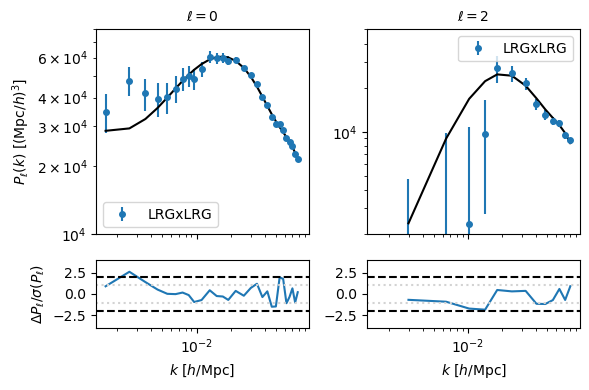

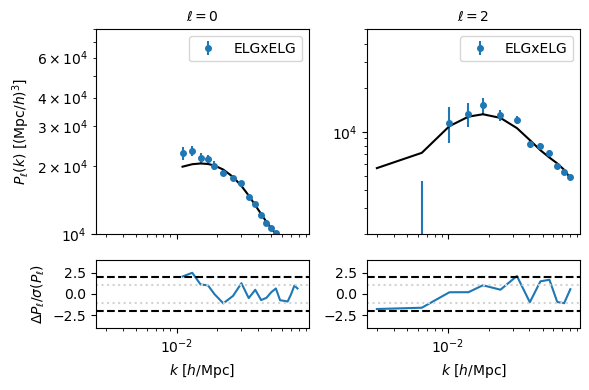

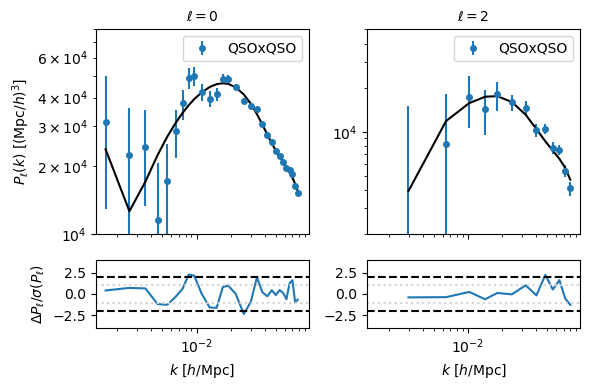

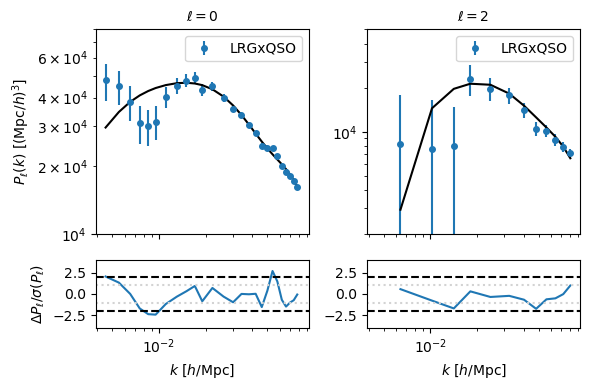

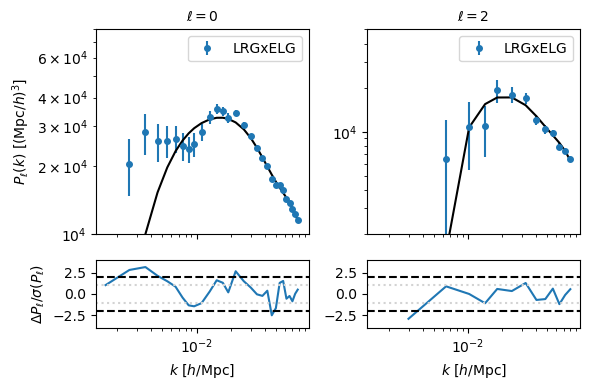

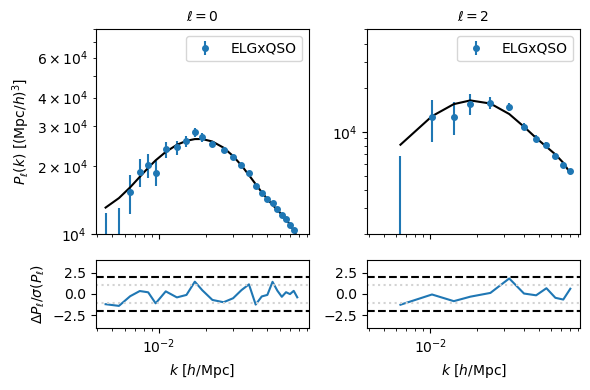

In [13]:
#plot_observables(observables)
for tracer in observables.keys():
    plot_observables({tracer: observables[tracer]})

In [ ]:
faire en sorte d'avoir un parametere pour savoir oquel params je fix ou j'associe (avec les nickanmes) -> demander à CLAUDE ? 

In [ ]:
def fix_likelihood_bias_and_damping(likelihood, tracer, zeffs, derived_cross_bias=True, nickname=None, available_tracers=None, **kwargs):
    """Apply bias and damping parameter relations between the paramters of the likelihood both for ell=0/2 and auto/cross power spectrum.

    Parameters
    ----------
    likelihood : desilike likelihood
        Likelihood whose parameters are updated in place.
    tracer : str
        name of the tracers: 'LRGxLRG', 'LRGxQSO', ... 
    nickname : str, optional
        Suffix inserted between the tracer shortname and '_ell{ell}' in the cross-correlation theory
        parameter names (e.g. nickname='LRGxELG' -> 'ELG_LRGxELG_ell0'). Must match the nickname used in
        get_obervable_and_likelihood. Default is None (no suffix, legacy behaviour).
    available_tracers : list or set, optional
        List of tracers for which complete data (including auto-correlations) is available.
        Used to determine which cross-correlation biases can be derived. If None, assumes all
        auto-correlations are available.

    Returns
    -------
    likelihood
        Same likelihood object, updated in place.
    """

    def _rescale_bias_params(likelihood, tracer, zeff):
        """ 
        Fix the bias parameters in the likelihood according to the redshift dependence of the bias.
        Only modifies the parameter if both source and target exist in the likelihood.

        Args:
            likelihood: The likelihood object.
            tracer: The tracer for which to fix the bias parameters. tracer[0] is source, tracer[1] is target.
            zeff: The effective redshifts.
        """
        from clustering_statistics import tools        
        source_param_name = f"{tracer[0]}.b1"
        target_param_name = f"{tracer[1]}.b1"
        
        # Both parameters must exist to create a derived relationship
        if source_param_name not in likelihood.all_params or target_param_name not in likelihood.all_params:
            logger.debug(f"Skipping derived relationship: {source_param_name} -> {target_param_name} (missing parameter)")
            return
            
        # b(z) = alpha * (1 + z)**2 + beta
        alpha, beta = tools.bias(1, tracer=tracer[0][:3], return_params=True)  
        factor = (alpha * (1 + zeff[1])**2 + beta) / (alpha * (1 + zeff[0])**2 + beta)
        likelihood.all_params[target_param_name].update(derived='{' + source_param_name + '}' + f' * {factor}')
        logger.debug(f"Derived relationship: {target_param_name} = {source_param_name} * {factor}")

    tracers = tracer.split('x')

    # Auto-correlation: link ell2 bias / damping to ell0.
    if tracers[0] == tracers[1]:
        if len(zeffs[tracer]) > 1:
            zeff = [zeffs[tracer][ell] for ell in [0, 2]]
            _rescale_bias_params(likelihood, tracer=[f"{tracers[0]}_ell0", f"{tracers[0]}_ell2"], zeff=zeff)
            # logger.warning('we neglect the redshift dependence of the damping term, for now') 
            param_name_ell0, param_name_ell2 = f"{tracers[0]}_ell0.sigmas",f"{tracers[0]}_ell2.sigmas"
            likelihood.all_params[param_name_ell2].update(derived='{' + param_name_ell0 + '}')
            logger.debug(f"Derived damping: {param_name_ell2} = {param_name_ell0}")

    # Cross-correlation: derive cross biases from auto biases or let it free.
    if tracers[0] != tracers[1]:
        cross_suffix = f'_{nickname}' if nickname is not None else ''
        for i, tt in enumerate(tracers):
            auto_tracer = 'x'.join([tt, tt])
            # Check if auto-tracer data is available
            print('TODO ICI')
            has_auto_data = (available_tracers is None) or (auto_tracer in available_tracers)
            
            if derived_cross_bias and has_auto_data:
                # derived the bias from the auto-correlation bias, taking into account the different effective redshifts of the auto and cross correlation.
                zeff = [zeffs[auto_tracer][0], zeffs[tracer][0]]
                _rescale_bias_params(likelihood, tracer=[f"{tt}_ell0", f'{tt}{cross_suffix}_ell0'], zeff=zeff)
            elif derived_cross_bias and not has_auto_data:
                # Auto-tracer not available or derived_cross_bias=False: let free the cross-correlation bias:
                logger.debug(f"Cannot derive bias for {tt}{cross_suffix} because auto-tracer {auto_tracer} data is not available. Letting cross-correlation bias free.")
            else:
                # let free the cross-correlation bias, but fix one of the two biases to break degeneracy.
                # the first linear bias parameter can be set with kwargs.          
                if i == 0:      
                    default_b1 = kwargs.get(f"{tt}{cross_suffix}_ell0.b1", 1)
                    likelihood.all_params[f"{tt}{cross_suffix}_ell0.b1"].update(value=default_b1, fixed=True) 
    
            if len(zeffs[tracer]) > 1:
                zeff = [zeffs[tracer][ell] for ell in [0, 2]]
                _rescale_bias_params(likelihood, tracer=[f"{tt}{cross_suffix}_ell0", f"{tt}{cross_suffix}_ell2"], zeff=zeff)
                # logger.warning('we neglect the redshift dependence of the damping term, for now')
                # Note: the first damping term is fixed to 0:
                if i == 1: likelihood.all_params[f"{tt}{cross_suffix}_ell2.sigmas"].update(derived='{' + f"{tt}{cross_suffix}_ell0.sigmas" + '}')


In [10]:
def build_total_likelihood(order, pks, observables, covs, zeffs, fiducial, scale_covariance=1):
    """ 
    Build the total likelihood for the combined data vector, by stacking the observables and using the combined covariance matrix.
    Were are using order to stack the observable in the same order as the covariance matrix. 
    Note: pks, observables, covs, zeffs, fiducial are dictionaries with keys corresponding to the labels in order.
    Note2: fiducial is used only to extract the redshift ranges for the different tracers, which are needed to rescale the off-diagonal blocks of the covariance matrix in combine_analytical_covariances.
    """
    from desilike.likelihoods import ObservablesGaussianLikelihood
    #from tools import combine_analytical_covariances, fix_likelihood_bias_and_damping

    total_observables = [observable for tracer in order for observable in observables[tracer]]
    logger.debug([ff.name for ff in total_observables])

    if isinstance(covs[order[0]], list):
        logger.info('Using mocks to estimate the covariance matrix.')
        covariance = np.cov(np.transpose([np.concatenate([covs[tt][i].match(pks[tt]).value() for tt in order]) for i in range(len(covs[order[0]]))]))
        correction_covariance = {'correction': 'hartlap-percival2014', 'nobs': len(covs[order[0]])}
    else:
        logger.info('Using analytical covariance matrix.')
        covariance = combine_analytical_covariances(pks, covs, order=order, fiducial=fiducial).value()
        correction_covariance = None
    
    total_likelihood = ObservablesGaussianLikelihood(observables=total_observables, covariance=covariance, 
                                                     correct_covariance=correction_covariance,scale_covariance=scale_covariance)
    for tracer in order: 
        # We do not link the damping term from the cross-correlation and the auto-correlation
        # Because they are different effective redshifts and we do not know the a priori.
        fix_likelihood_bias_and_damping(total_likelihood, tracer=tracer, zeffs=zeffs, derived_cross_bias=True, nickname=tracer, available_tracers=order)
    total_likelihood()

    return total_likelihood

In [ ]:

# CA NE VA PAS COMME JE VEUX -> IL FAUT QUE JE PUISSE DONNE UN MAPPING ENTRE LES PARAMETRES QUE JE VEUX FIXER ET LES PARAMETRES DE LA LIKELIHOOD, AVEC DES NICKNAMES POUR LES PARAMETRES DE LA CROSS CORRELATION.

PARCEQUE LA SI J4AI DEUX CROSS AVEC LES ELGS CA NE MARCHE PAS :(

[000134.79] [0/1] 04-27 18:30  FIT PNG                   INFO     Using mocks to estimate the covariance matrix.
[000135.06] [0/1] 04-27 18:30  ObservablesGaussianLikelihood INFO     Covariance matrix with 122 points built from 998 observations.
[000135.07] [0/1] 04-27 18:30  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.8766.
[000135.95] [0/1] 04-27 18:30  ObservablesGaussianLikelihood INFO     Covariance matrix with 122 points built from 998 observations, varying 10 parameters.
[000135.95] [0/1] 04-27 18:30  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.1143.
[000135.97] [0/1] 04-27 18:30  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_LRGxELG_ell0xELG_LRGxELG_ell0.sn0', 'ELG_LRGxELG_ell0.b1', 'ELG_LRGxELG_ell0.sigmas', 'LRG_LRGxQSO_ell0xQSO_LRGxQSO_ell0.sn0', 'QSO_LRGxQSO_ell0.b1', 'QSO_LRGxQSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000136.42] [0/1] 04-27 18:30

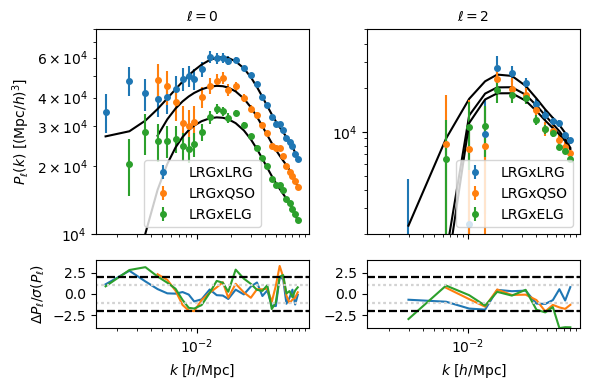

In [13]:
#order = ['LRGxELG', 'ELGxQSO']
#orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG']]

order = ['LRGxLRG', 'LRGxQSO', 'LRGxELG']

likelihood = build_total_likelihood(order, pks, observables, mocks, zeffs, fiducial)

profilers['-'.join(order)] = run_profiler(likelihood)
plot_observables({tt: observables[tt] for tt in order})

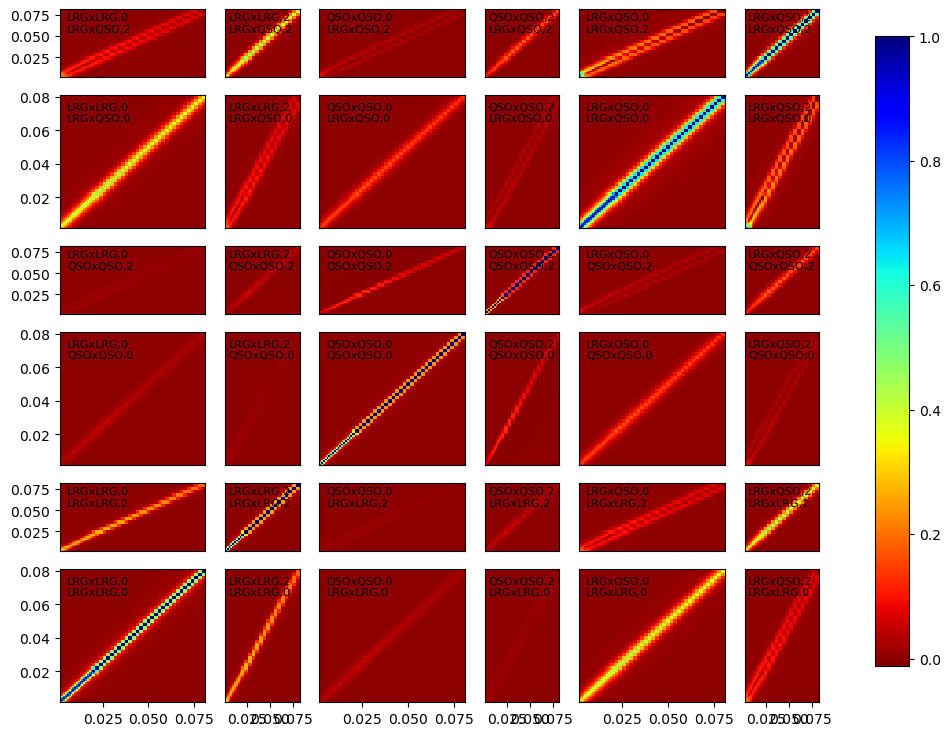

[000174.81] [0/1] 04-13 17:30  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000175.66] [0/1] 04-13 17:30  MinuitProfiler            INFO     Successfully jit input likelihood.
[000319.42] [0/1] 04-13 17:33  PNG fitting tools         INFO     
+------------------------------------------+--------+-----------+---------+
| chi2 / (222 - 9) = 3109.24 / 213 = 14.60 | varied |  bestfit  |  error  |
+------------------------------------------+--------+-----------+---------+
|                 fnl_loc                  |  True  | -22.72362 | 0.00055 |
|    LRG_cross_ell0xQSO_cross_ell0.sn0     |  True  |  0.3404   | 0.0052  |
|          QSO_cross_ell0.sigmas           |  True  |   0.00    |  0.69   |
|               QSO_ell0.sn0               |  True  |   0.918   |  0.013  |
|               QSO_ell0.b1             

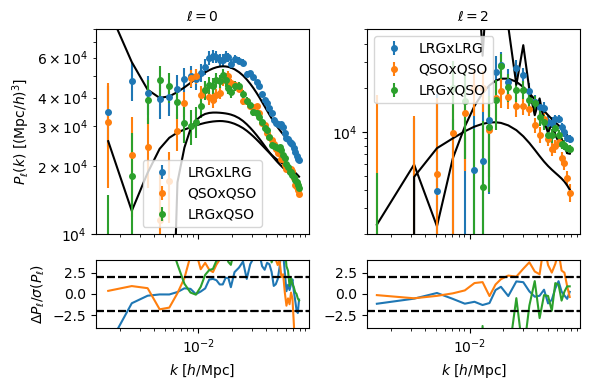

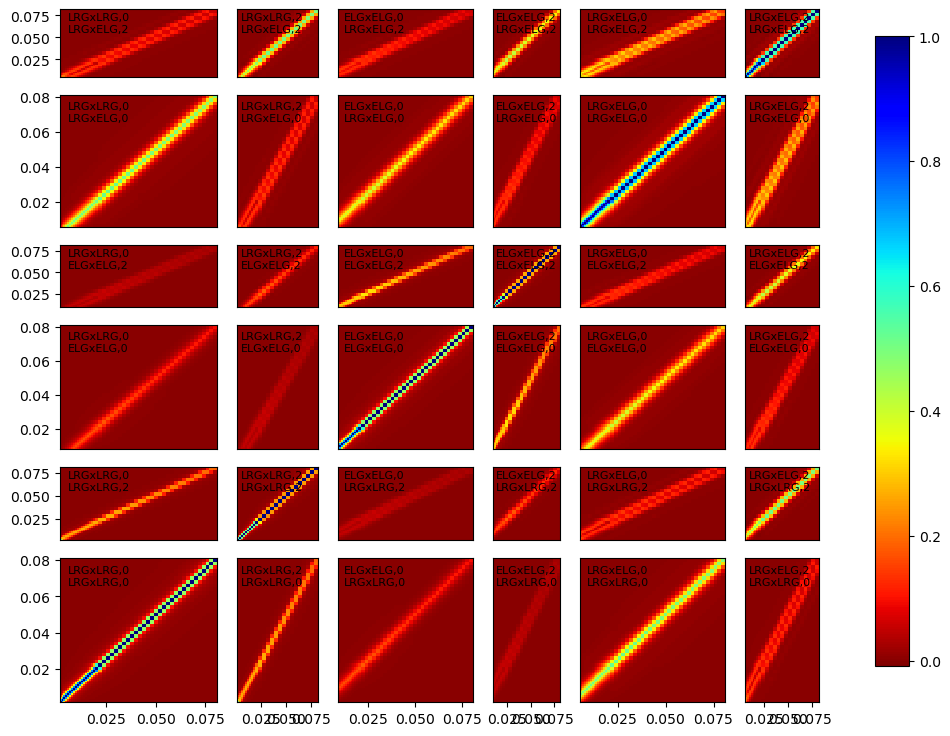

[000321.96] [0/1] 04-13 17:33  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xELG_cross_ell0.sn0', 'ELG_cross_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000322.75] [0/1] 04-13 17:33  MinuitProfiler            INFO     Successfully jit input likelihood.
[000446.97] [0/1] 04-13 17:35  PNG fitting tools         INFO     
+---------------------------------------------------+--------+---------+-------+
| chi2 / (205 - 9) = 120961870.49 / 196 = 617152.40 | varied | bestfit | error |
+---------------------------------------------------+--------+---------+-------+
|                      fnl_loc                      |  True  | -5.3e0  |  nan  |
|         LRG_cross_ell0xELG_cross_ell0.sn0         |  True  | 6.1e-2  |  nan  |
|               ELG_cross_ell0.sigmas               |  True  | 10.0e0  |  nan  |
|                   ELG_ell0.sn0                    |  True  | 5.2e-1  |  nan  |
|    

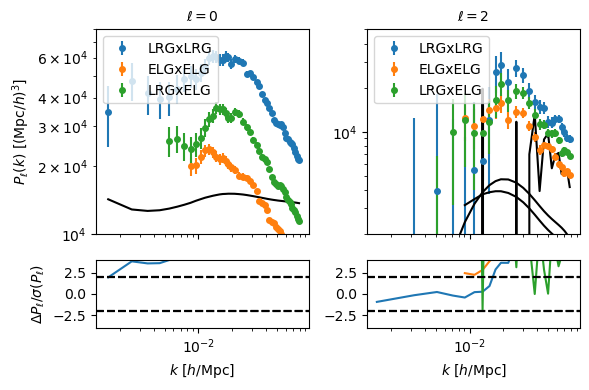

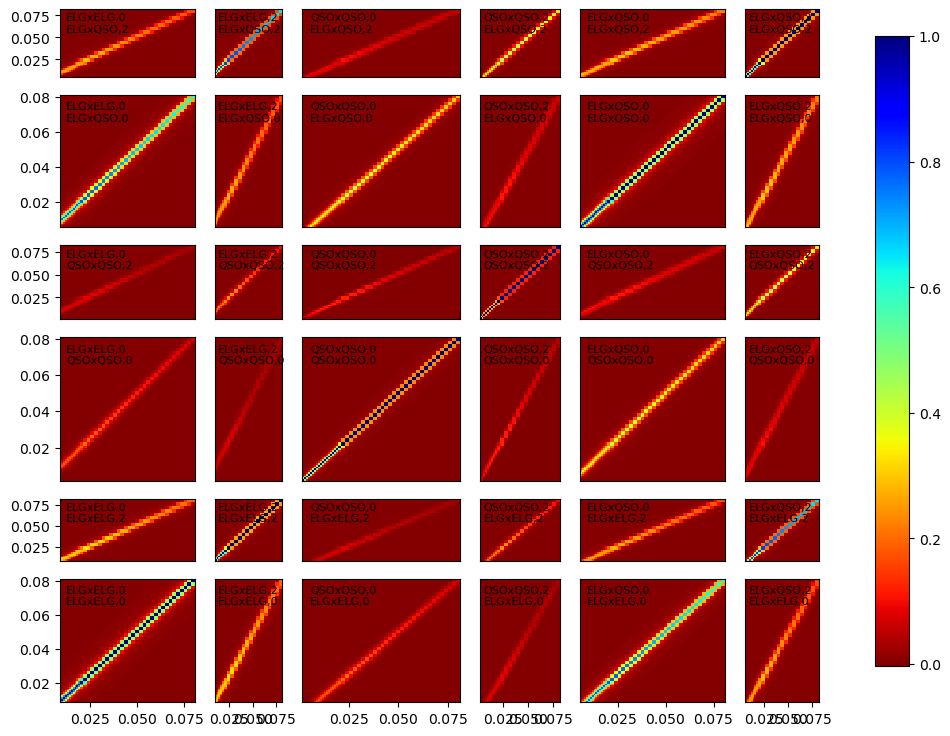

[000449.80] [0/1] 04-13 17:35  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'ELG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas'].
[000450.50] [0/1] 04-13 17:35  MinuitProfiler            INFO     Successfully jit input likelihood.
[000469.03] [0/1] 04-13 17:35  PNG fitting tools         INFO     
+----------------------------------------+--------+---------+-------+
| chi2 / (205 - 9) = 369.37 / 196 = 1.88 | varied | bestfit | error |
+----------------------------------------+--------+---------+-------+
|                fnl_loc                 |  True  |   8.5   |  2.9  |
|   ELG_cross_ell0xQSO_cross_ell0.sn0    |  True  |  0.031  | 0.018 |
|         QSO_cross_ell0.sigmas          |  True  |  5.37   | 0.52  |
|              QSO_ell0.sn0              |  True  | -0.116  | 0.037 |
|              QSO_ell0.b1               |  True  |  3.138  | 0.033 |
|           

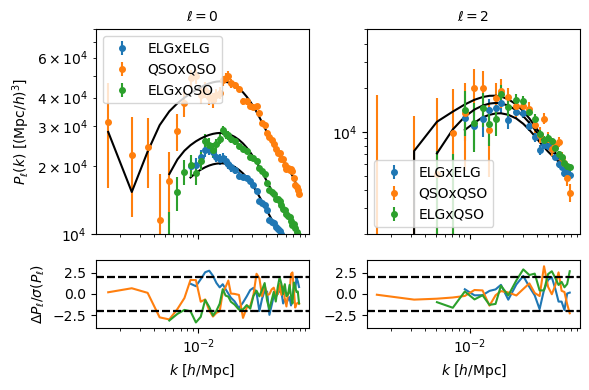

In [ ]:
#order = ['LRGxELG', 'ELGxQSO']
orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO'], ['LRGxLRG', 'ELGxELG', 'LRGxELG'], ['ELGxELG', 'QSOxQSO', 'ELGxQSO']]

for order in orders:
    likelihoods['-'.join(order)] = build_total_likelihood(order, pks, observables, covs, zeffs, fiducial)

    #if ana_cov and True: plot_corr(likelihoods.cov, fn=None)

    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tt: observables[tt] for tt in order})

In [ ]:
# This does not work for now because I need to name differently the paramters name in the theory to have different bias /sigmas / as a funciton of the three likelihoods !


orders = [['LRGxLRG', 'ELGxELG','QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

for order in orders:
    likelihoods['-'.join(order)] = build_total_likelihood(order, pks, observables, covs, zeffs, fiducial, plot_cov=True)
    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tt: observables[tt] for tt in order})

In [ ]:
# We do not link the damping term from the cross-correlation and the auto-correlation
# Because they are different effective redshifts and we do not know the a priori.

In [172]:
# samplers = {}

# for tracer in likelihoods.keys():
#     logger.info(f'Run MCMC for {tracer=}:')
#     samplers[tracer] =  run_mcmc(likelihoods[tracer], max_iterations=20000, check_every=5000)

In [173]:
# from desilike.samples import Chain

# burnin, thin = 0.3, 10

# chains = {}

# #chains = Chain.concatenate([Chain.load(fn_chains[key].replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(nchains)])

# for tracer in samplers.keys():
#      chains[tracer] = Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in samplers[tracer].chains])
#      print(f'Nbr points for {tracer=}: {chains[tracer]["fnl_loc"].size}')

# params = ['fnl_loc', 'LRG_ell0.b1', 'LRG_ell0.sn0', 'LRG_ell0.sigmas', 'QSO_ell0.b1', 'QSO_ell0.sn0', 'QSO_ell0.sigmas', 'QSO_cross_ell0.b1', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas']
# xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$']

# plot_triangle([chains[tracer] for tracer in chains.keys()], params, legend_labels=list(chains.keys()), xlabels=xlabels, 
#               filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

# plot_triangle([chains[tracer] for tracer in chains.keys()], ['fnl_loc'], legend_labels=list(chains.keys()), xlabels=[r'$f_{\rm NL}^{\rm loc}$'], 
#               filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

In [175]:
## PLUS J4IA PAS UN BEAU PK ALORS QUE AVANT JEN AVAIS UN ! KEPASA ??   --> COMPARER AVEC DR2 FKP 

In [ ]:
import lsstypes 

seeds = [85, 95, 75, 65, 91, 37, 46, 87, 19, 38]

ttest = [lsstypes.read(stats_dir / f'window_mesh2_spectrum_poles_fm_QSO_z0.8-3.5_NGC_weight-default-fkp-oqe_geometry_0_seed={seed}.h5') for seed in seeds]

ttest[2].value()

In [3]:
print(stats_dir)

NameError: name 'stats_dir' is not defined

In [24]:
tt = lsstypes.read(stats_dir / 'window_mesh2_spectrum_poles_fm_QSO_z0.8-3.5_NGC_weight-default-fkp-oqe_geometry_0_seed=1.h5')

In [25]:
tt.value()

array([[ 3.59774105e-01,  1.14347095e-02, -1.48626313e-04, ...,
        -7.89106102e+00,  4.47599972e+00,  1.09536495e+00],
       [ 5.04086318e-01, -6.35115514e-03,  7.50905318e-03, ...,
         9.08098369e-01,  1.61208473e+00, -4.66202297e+00],
       [ 5.59016867e-01,  6.52128506e-03,  1.70447782e-02, ...,
         5.12298302e-01,  2.78599483e+00, -1.39614329e+01],
       ...,
       [ 9.83820667e-06,  7.72027084e-04,  2.19541942e-03, ...,
        -9.53069456e-03,  5.10627048e-02, -7.86010903e-02],
       [ 1.91603948e-05,  7.41575997e-04,  2.01276517e-03, ...,
        -2.57997251e-03,  7.70670757e-02, -4.59769363e-02],
       [ 2.52278176e-05,  7.84904583e-04,  2.03625971e-03, ...,
        -1.52722733e-02,  5.70130979e-02,  1.89816888e-02]],
      shape=(157, 45))